In [18]:
import os, warnings, json, platform, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정의 ─────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']

try:
    GPU_AVAILABLE = subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0
except:
    GPU_AVAILABLE = False
XGB_DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'
LGB_DEVICE  = 'gpu'  if GPU_AVAILABLE else 'cpu'
print(f'✅ 라이브러리 로드 완료')
print(f'   GPU: {GPU_AVAILABLE} | XGB={XGB_DEVICE} | LGB={LGB_DEVICE}')
print('✅ 라이브러리 로드 완료')


✅ 라이브러리 로드 완료
   GPU: True | XGB=cuda | LGB=gpu
✅ 라이브러리 로드 완료


In [19]:
# FD002 원본 데이터 로딩
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD002 로딩  Train:{train_raw.shape}  Test:{test_raw.shape}  RUL:{rul_df.shape}')


✅ FD002 로딩  Train:(53759, 26)  Test:(33991, 26)  RUL:(259, 1)


In [20]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': ['s_16'],
    'useful_sensors': ['s_1', 's_2', 's_3', 's_4', 's_5', 's_', 's_7', 's_8', 's_9',
                       's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21'],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 125,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': 2,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'standard',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
    'lags':         [10, 50, 100],     # 예: [] / [1] / [1,2] / [1,3,5,10] ...
    'diffs':        [10, 50, 70],           # 차분 윈도우
    'rolling_means':[10, 40, 100],        # rolling mean 윈도우들
    'rolling_stds': [10, 50, 100],        # rolling std 윈도우들
    'emas':         [20, 70, 100],           # EMA span (정수)
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 1e-3
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : ['s_16']
   useful_sensors        : ['s_1', 's_2', 's_3', 's_4', 's_5', 's_', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']
   rul_cap               : 125
   gaussian_sigma        : 2
   normalize             : standard
   lags                  : [10, 50, 100]
   diffs                 : [10, 50, 70]
   rolling_means         : [10, 40, 100]
   rolling_stds          : [10, 50, 100]
   emas                  : [20, 70, 100]


In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.ndimage import gaussian_filter1d

# 1. 센서 필터링 (기존 동일)
def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=1e-5):
    train_std = train_df[sensor_cols].std()
    auto_remove = set(train_std[train_std < const_thr].index.tolist())
    manual_set  = set(manual_remove or [])
    remove = sorted(auto_remove | manual_set, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    useful = sorted([s for s in sensor_cols if s not in remove],
                    key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove

# 2. 클러스터링 (기존 동일)
def add_op_cluster(train_df, test_df, op_cols, k, random_state=42):
    op_scaler = MinMaxScaler()
    Xz_tr = op_scaler.fit_transform(train_df[op_cols])
    Xz_te = op_scaler.transform(test_df[op_cols])
    
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    km.fit(Xz_tr)
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df['op_cluster'] = km.labels_
    test_df['op_cluster'] = km.predict(Xz_te)
    
    return train_df, test_df, km, op_scaler

# 3. Piecewise RUL (기존 동일)
def add_piecewise_rul(df, cap):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

# 4. 가우시안 스무딩 (엔진-클러스터-사이클 정렬)
def apply_gaussian_by_cluster(df, features, sigma):
    # 환경별로 묶어서 노이즈 제거 (물리적 왜곡 방지)
    df = df.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles']).reset_index(drop=True)
    def _smooth_func(s):
        if len(s) > 1:
            return gaussian_filter1d(s.values.astype(np.float32), sigma=sigma, mode='nearest')
        return s.values
    for col in features:
        df[col] = df.groupby(['unit_nr', 'op_cluster'])[col].transform(_smooth_func)
    return df

# 5. 엔진 단위 분할 (기존 동일)
def split_by_unit(train_df, valid_ratio, random_state):
    units = train_df['unit_nr'].unique()
    sub_units, val_units = train_test_split(units, test_size=valid_ratio, random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_units)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_units)].copy().reset_index(drop=True)
    return sub, val, sub_units, val_units

# 6. 클러스터별 정규화 (엔진-클러스터-사이클 정렬)
def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scalers = {}
    sub = sub.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles'])
    val = val.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles'])
    test = test.copy().sort_values(['unit_nr', 'op_cluster', 'time_cycles'])
    
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        scaler_c = ScalerCls()
        if mask.sum() > 0:
            sub.loc[mask, features] = scaler_c.fit_transform(sub.loc[mask, features])
            scalers[c] = scaler_c
        else: scalers[c] = None 
            
    for df_target in [val, test]:
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0 and scalers[c] is not None:
                df_target.loc[mask, features] = scalers[c].transform(df_target.loc[mask, features])
    return sub, val, test, scalers

# 7. 시계열 파생변수 생성 (엔진-사이클 정렬로 재정렬)
def add_temporal_features(df, sensor_cols, lags, diffs, rolls, roll_stds, emas):
    # 시간 순서대로 다시 줄 세우기 (핵심!)
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    for s in sensor_cols:
        grp = df.groupby(['unit_nr'])[s] # 클러스터 무시하고 엔진별로 시간순 계산
        for lag in (lags or []): df[f'{s}_lag{lag}'] = grp.shift(lag)
        for d in (diffs or []): df[f'{s}_diff{d}'] = grp.diff(d)
        for r in (rolls or []): df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []): df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []): df[f'{s}_ema{span}'] = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)

# 8. OHE 추가 (기존 동일)
def add_ohe_cluster(df, n_clusters):
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns: ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True), ohe[ohe_cols].reset_index(drop=True)], axis=1), ohe_cols

# [최종] 통합 실행 함수
def run_pipeline(train_raw, test_raw, cfg):
    # 1~3단계를 거치며 기본 세팅
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    tr2, te2, kmeans, op_scaler = add_op_cluster(train_raw[ID_COLS+OP_COLS+useful], test_raw[ID_COLS+OP_COLS+useful], OP_COLS, N_CLUSTERS, RANDOM_STATE)
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    
    # 4. 가우시안 (환경별 정렬)
    tr4 = apply_gaussian_by_cluster(tr3, useful, sigma=cfg['gaussian_sigma'])
    te4 = apply_gaussian_by_cluster(te2, useful, sigma=cfg['gaussian_sigma'])
    
    # 5. 분할
    sub5, val5, _, _ = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    
    # 6. 정규화 (환경별 정렬)
    sub6, val6, test6, scalers = normalize_by_cluster(sub5, val5, te4, useful, cfg['normalize'], N_CLUSTERS)
    
    # 7. 파생변수 (시간순 재정렬)
    sub7 = add_temporal_features(sub6, useful, cfg['lags'], cfg['diffs'], cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    val7 = add_temporal_features(val6, useful, cfg['lags'], cfg['diffs'], cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    test7 = add_temporal_features(test6, useful, cfg['lags'], cfg['diffs'], cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    
    # 8. OHE 및 최종 피처 정리
    sub8, ohe_cols = add_ohe_cluster(sub7, N_CLUSTERS)
    val8, _        = add_ohe_cluster(val7, N_CLUSTERS)
    test8, _       = add_ohe_cluster(test7, N_CLUSTERS)
    
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster', 'RUL', 'RUL_raw'])
    final_features = [c for c in sub8.columns if c not in EXCLUDE]
    
    return {
        'subtrain_ml': sub8, 'valid_ml': val8, 'test_ml': test8,
        'ml_features': final_features, 'kmeans': kmeans, 'op_scaler': op_scaler, 'scalers': scalers
    }

In [22]:
# ============================================================
# 🚀 파이프라인 실행 (최적화 및 통합본 대응)
# ============================================================
# 1. 파이프라인 실행
data = run_pipeline(train_raw, test_raw, CONFIG)

# 2. 결과 데이터 추출
train_ml    = data['subtrain_ml']
valid_ml    = data['valid_ml']
test_ml     = data['test_ml']
ML_FEATURES = data['ml_features']

# 3. 추가 정보 추출 (필요 시 사용)
kmeans_model = data['kmeans']
op_scaler    = data['op_scaler']
scalers_dict = data['scalers']

# 4. 결과 출력
print(f'\n[실행 결과]')
print(f'  - Sub-train 형태: {train_ml.shape}')
print(f'  - Valid 형태:     {valid_ml.shape}')
print(f'  - Test 형태:      {test_ml.shape}')
print(f'  - 최종 ML 피처 수: {len(ML_FEATURES)}개')

# 5. 피처 리스트 확인 (상위 10개만)
print(f'  - 주요 피처 예시: {ML_FEATURES[:20]}...')


[실행 결과]
  - Sub-train 형태: (43464, 334)
  - Valid 형태:     (10295, 334)
  - Test 형태:      (33991, 332)
  - 최종 ML 피처 수: 326개
  - 주요 피처 예시: ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_18', 's_19', 's_20', 's_21']...


In [23]:
# ============================================================
# 🚀 파이프라인 실행 및 데이터 최종 준비
# ============================================================

# 1. 파이프라인 실행
# (내부에서 클러스터링 -> 정규화 -> 유효센서 선택 -> EMA 생성 -> OHE 완료)
data = run_pipeline(train_raw, test_raw, CONFIG)

# 2. 결과 데이터 추출
train_ml    = data['subtrain_ml']
valid_ml    = data['valid_ml']
test_ml     = data['test_ml']
ML_FEATURES = data['ml_features']

# 3. XGBoost 학습을 위한 X(Input), y(Target) 분리
X_train = train_ml[ML_FEATURES]
y_train = train_ml['RUL']

X_val   = valid_ml[ML_FEATURES]
y_val   = valid_ml['RUL']

X_test  = test_ml[ML_FEATURES]
# 테스트셋의 실제 RUL은 보통 별도의 파일(RUL_FD004.txt)에 있으므로 
# evaluate_full_pipeline 함수 내부에서 처리하거나 별도로 불러와야 합니다.

# 4. 결과 및 피처 상태 출력
print(f'\n[데이터 준비 완료]')
print(f'  - Train 피처(X) 형태: {X_train.shape} | 라벨(y) 형태: {y_train.shape}')
print(f'  - Valid 피처(X) 형태: {X_val.shape}   | 라벨(y) 형태: {y_val.shape}')


# 5. 피처 리스트 최종 점검 (의도치 않은 컬럼 포함 여부 확인)
# ID_COLS나 OP_COLS가 포함되어 있지 않아야 합니다.
print(f'\n[피처 리스트 점검 (상위 15개)]')
print(ML_FEATURES[:15])

# 6. 추가 정보 보관 (나중에 추론 시 필요)
kmeans_model = data['kmeans']
scalers_dict = data['scalers']


[데이터 준비 완료]
  - Train 피처(X) 형태: (43464, 326) | 라벨(y) 형태: (43464,)
  - Valid 피처(X) 형태: (10295, 326)   | 라벨(y) 형태: (10295,)

[피처 리스트 점검 (상위 15개)]
['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15']


In [24]:
# 흩어진 데이터를 다시 엔진-사이클 순으로 정렬
train_ml = train_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
valid_ml = valid_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
test_ml  = test_ml.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)

In [25]:
# ML 전용 라이브러리
import time
import joblib
import optuna
import mlflow
import mlflow.sklearn
import shap
import seaborn as sns

from optuna.samplers import TPESampler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ ML 라이브러리 로드 완료')

✅ ML 라이브러리 로드 완료


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve

# --- 1. 데이터 준비 (X, y 분리 및 Test 세트 구성) ---
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val, y_val = valid_ml[ML_FEATURES], valid_ml['RUL']

# Test 평가는 각 엔진의 '마지막 사이클'만 추출하여 수행
test_last = test_ml.groupby('unit_nr').last().reset_index()
X_test = test_last[ML_FEATURES]
y_test = rul_df['RUL'].values 

# --- 2. NASA Score 함수 ---
def calculate_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

# --- 3. 통합 시각화 함수 (6개 그래프) ---
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False, eval_results=None):
    # 예측
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    
    # 지표 계산
    results = {
        'Train': [np.sqrt(mean_squared_error(y_train, pred_train)), calculate_nasa_score(y_train, pred_train)],
        'Valid': [np.sqrt(mean_squared_error(y_val, pred_val)), calculate_nasa_score(y_val, pred_val)],
        'Test':  [np.sqrt(mean_squared_error(y_test, pred_test)), calculate_nasa_score(y_test, pred_test)]
    }
    
    print(f"\n" + "="*50 + f"\n 🏆 {model_name} 최종 평가 결과 \n" + "="*50)
    for k, v in results.items():
        print(f" [{k}] RMSE: {v[0]:.4f} | NASA Score: {v[1]:.2f}")
    
    # 시각화 (2x3)
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    plt.subplots_adjust(hspace=0.3)
    
    # (1) Learning Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_scores, v_scores = learning_curve(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error')
        ax1.plot(sizes, -np.mean(t_scores, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_scores, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('1. Learning/Loss Curve')
    ax1.legend(); ax1.grid(True)

    # (2) Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange')
    axes[0, 1].axhline(0, color='red', linestyle='--')
    axes[0, 1].set_title('2. Residual Plot (Validation)')

    # (3) Feature Importance
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    idx = np.argsort(imp)[-15:]
    ax3.barh(range(15), imp[idx], color='teal')
    ax3.set_yticks(range(15)); ax3.set_yticklabels(np.array(ML_FEATURES)[idx])
    ax3.set_title('3. Top 15 Features')

    # (4) Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val, label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred', ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('4. Target Distribution (Val)'); axes[1, 0].legend()

    # (5) Weight/Importance Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('5. Feature Weight Histogram')

    # (6) [NEW] Test Actual vs Prediction Line Graph
    ax6 = axes[1, 2]
    ax6.plot(y_test, label='Actual RUL', color='black', linewidth=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', linestyle='--', alpha=0.8)
    ax6.set_title('6. Test: Actual vs Predicted Line Graph')
    ax6.set_xlabel('Engine Unit (Index)'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)
    
    plt.show()


 🏆 Ridge 최종 평가 결과 
 [Train] RMSE: 11.4528 | NASA Score: 83114.62
 [Valid] RMSE: 12.8175 | NASA Score: 30710.08
 [Test] RMSE: 26.0497 | NASA Score: 5491.48


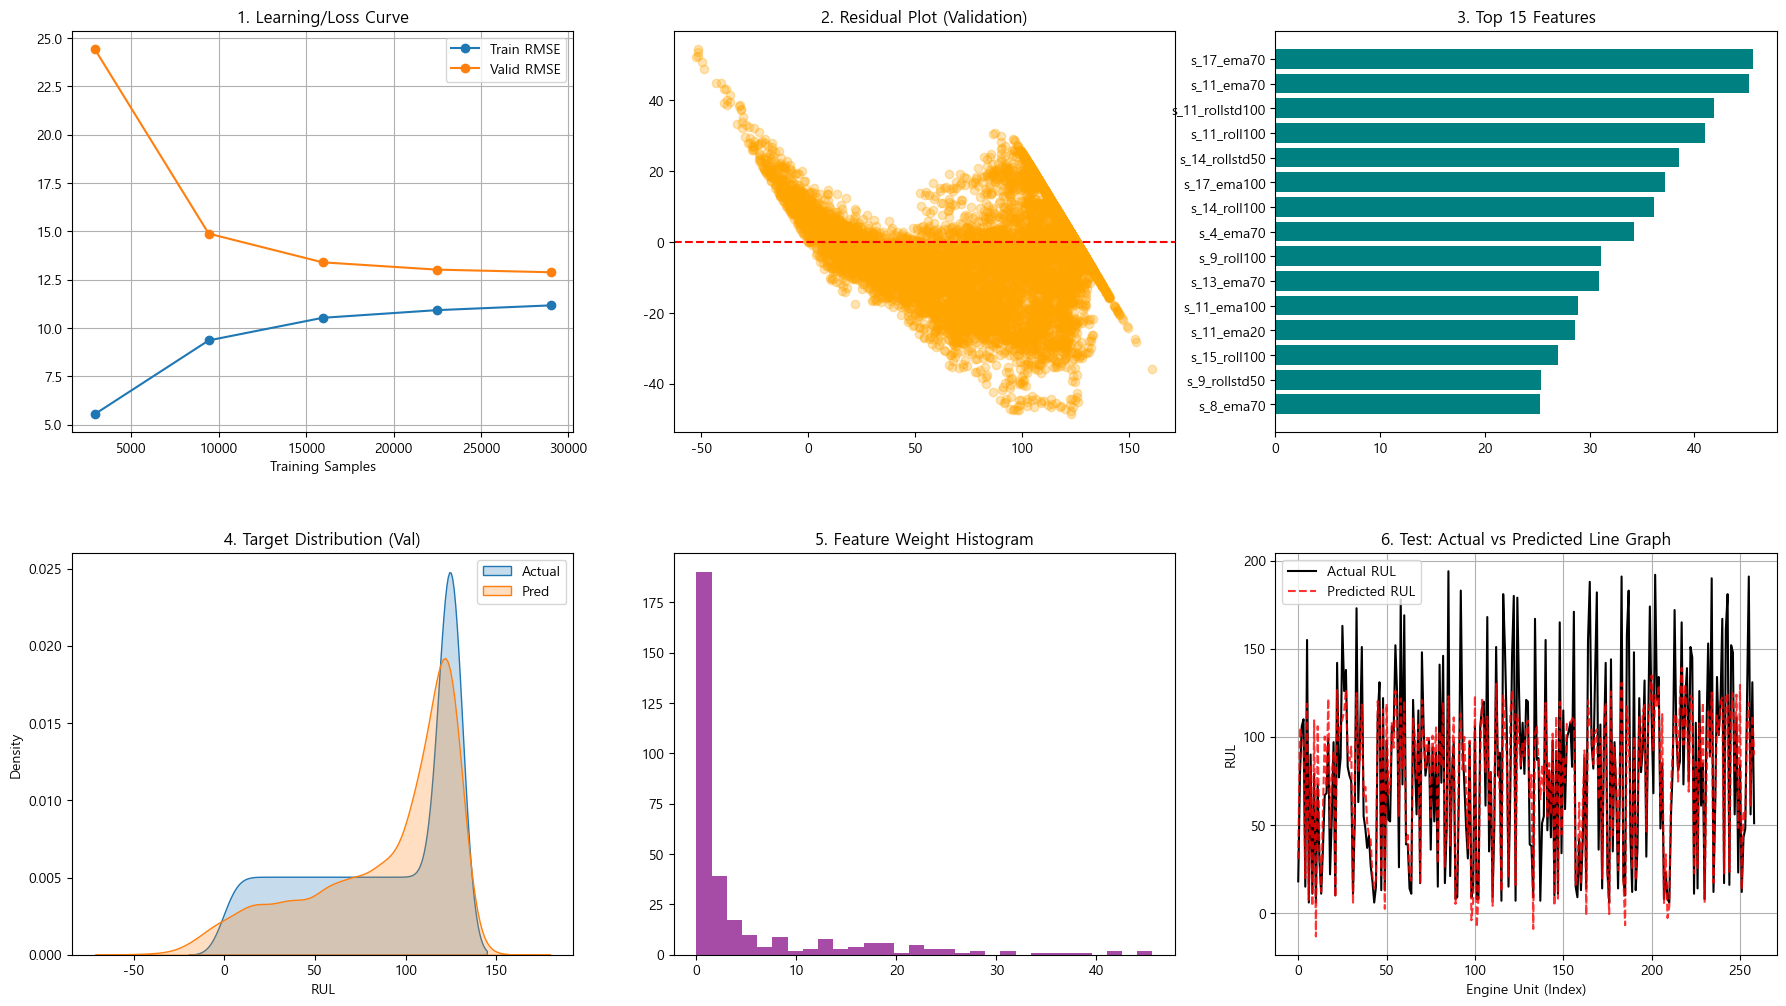

In [27]:
from sklearn.linear_model import Ridge

# --- 하이퍼파라미터 설정 ---
ridge_params = {
    'alpha': 1.0,           # 규제 강도 (클수록 규제 강화)
    'solver': 'auto',       # 최적화 알고리즘 ('auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga')
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_ridge = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_ridge, "Ridge")


 🏆 Lasso 최종 평가 결과 
 [Train] RMSE: 11.7096 | NASA Score: 86894.51
 [Valid] RMSE: 12.4361 | NASA Score: 27768.13
 [Test] RMSE: 26.1255 | NASA Score: 5795.86


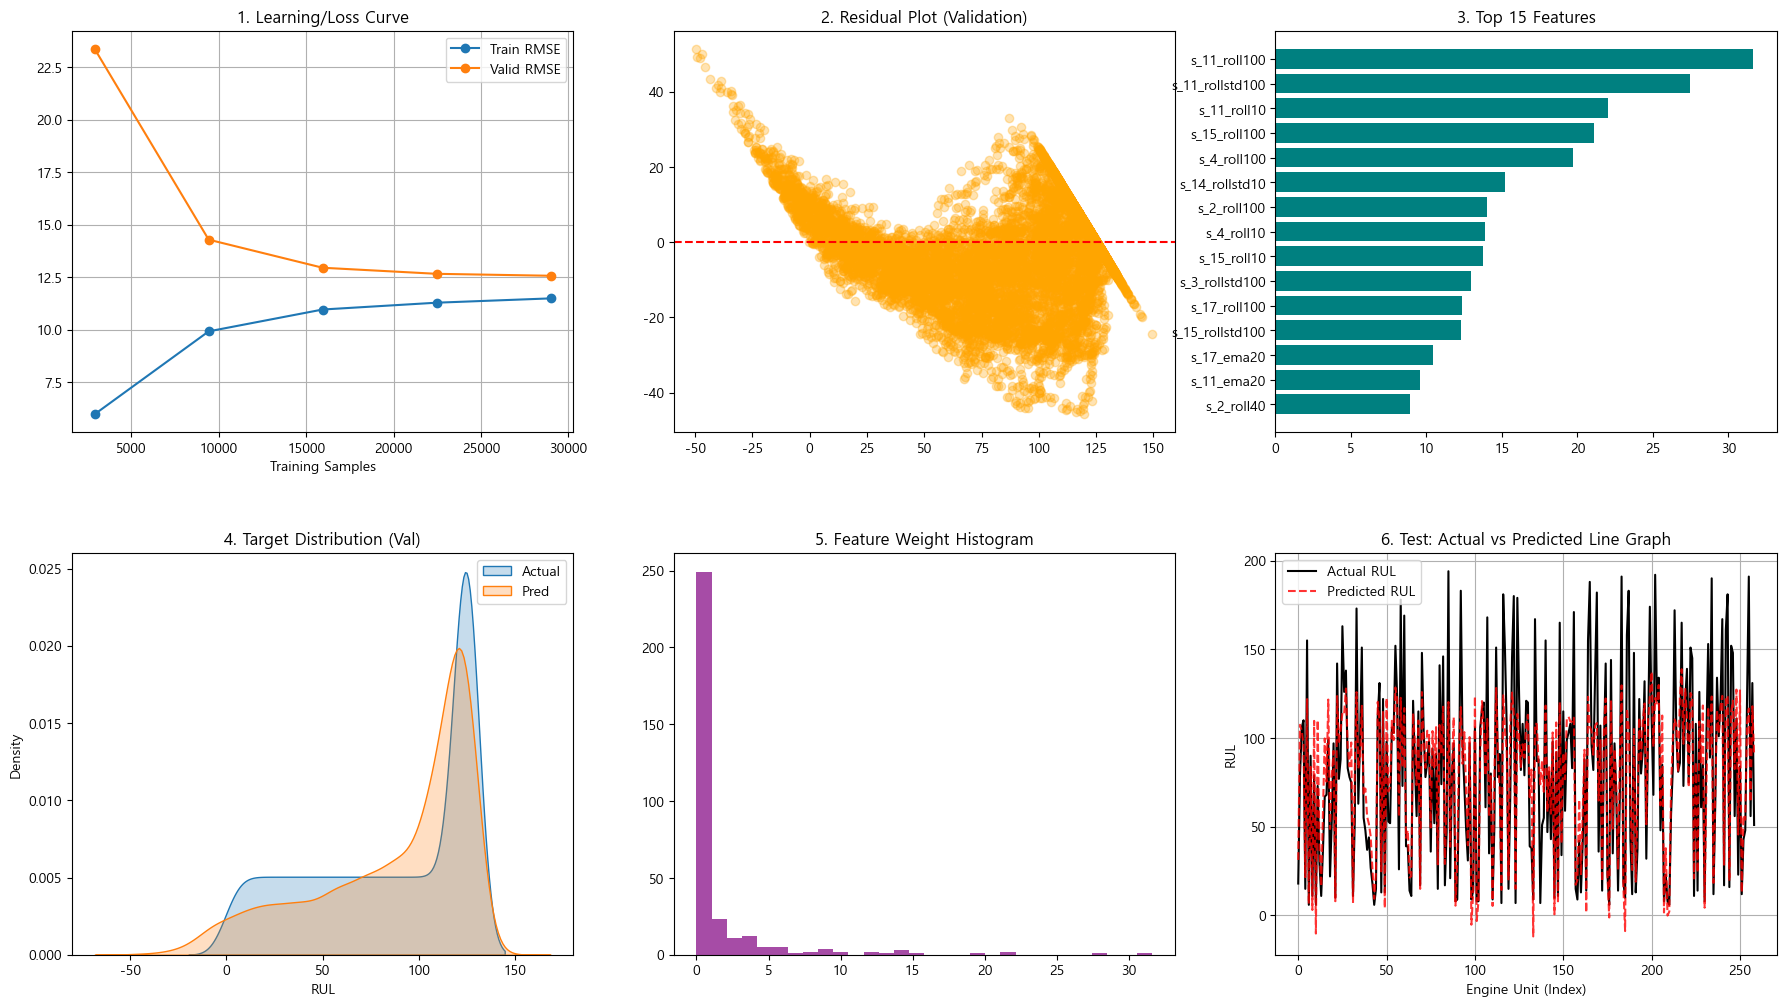

In [28]:
from sklearn.linear_model import Lasso

# --- 하이퍼파라미터 설정 ---
lasso_params = {
    'alpha': 0.01,           # 규제 강도 (불필요한 피처의 가중치를 0으로 만듦)
    'selection': 'cyclic',  # 가중치 업데이트 방식 ('cyclic', 'random')
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_lasso = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_lasso, "Lasso")


 🏆 ElasticNet Regression 최종 평가 결과 
 [Train] RMSE: 12.9372 | NASA Score: 110805.29
 [Valid] RMSE: 12.9663 | NASA Score: 29208.53
 [Test] RMSE: 26.7787 | NASA Score: 5737.51


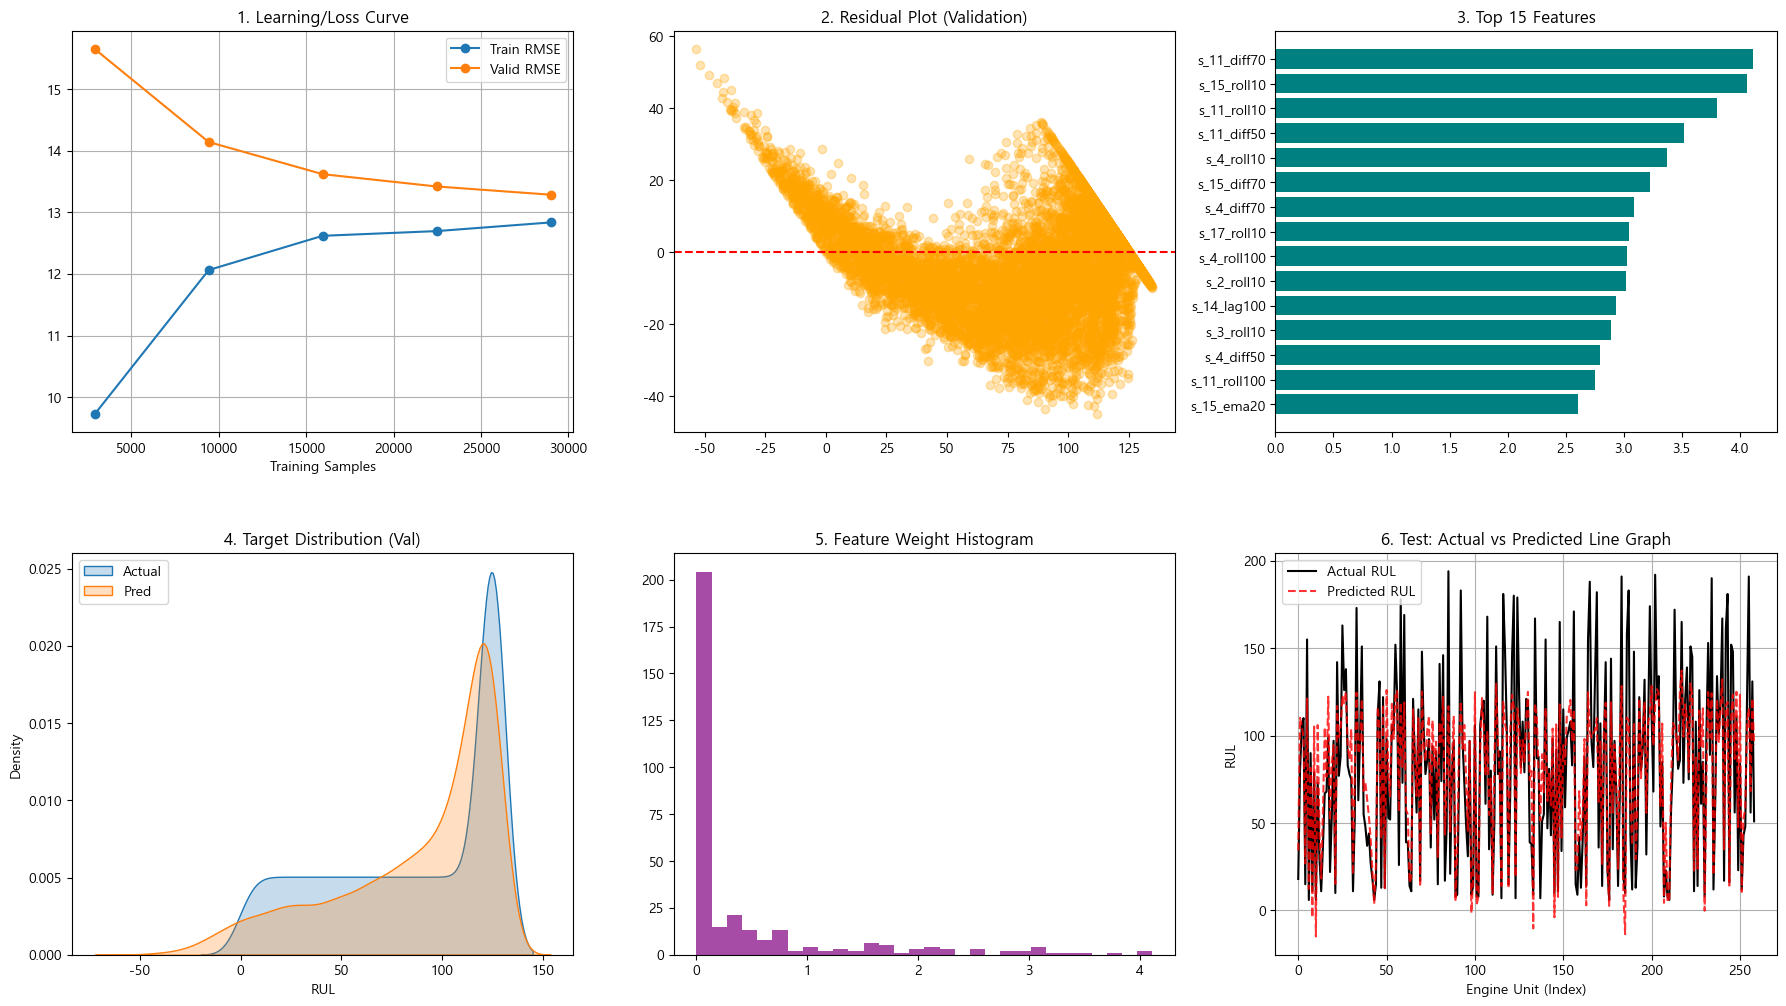

In [29]:
from sklearn.linear_model import ElasticNet

# --- 하이퍼파라미터 설정 ---
elastic_params = {
    'alpha': 0.1,           # 전체 규제 강도
    'l1_ratio': 0.5,        # L1 규제의 비율 (0이면 Ridge, 1이면 Lasso와 동일)
    'selection': 'cyclic',  # 가중치 업데이트 방식
    'max_iter': 2000,       # 최대 반복 횟수
    'tol': 0.0001,          # 수렴 기준
    'random_state': 42
}

# 모델 초기화 및 학습
model_elastic = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_elastic, "ElasticNet Regression")


 🏆 Random Forest 최종 평가 결과 
 [Train] RMSE: 7.1453 | NASA Score: 37777.10
 [Valid] RMSE: 10.6633 | NASA Score: 21213.97
 [Test] RMSE: 24.8700 | NASA Score: 5520.68


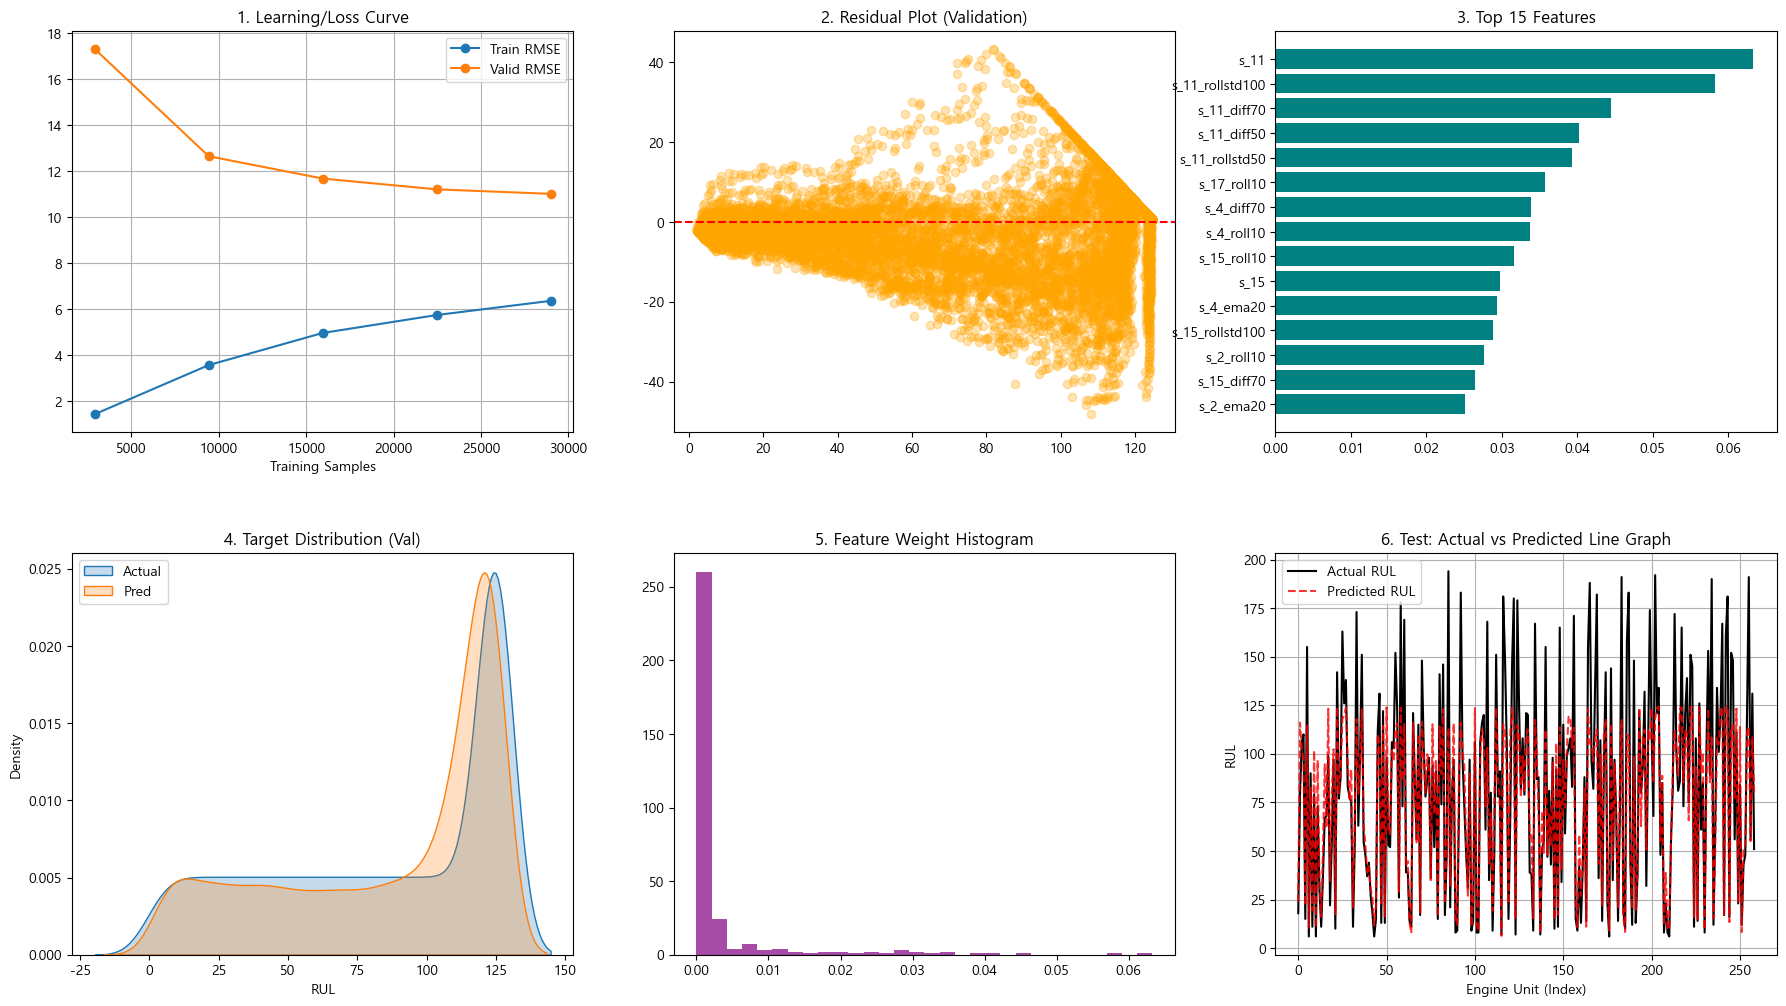

In [30]:
from sklearn.ensemble import RandomForestRegressor

# --- 하이퍼파라미터 설정 ---
rf_params = {
    'n_estimators': 200,      # 생성할 트리의 개수
    'max_depth': 10,          # 트리의 최대 깊이 (과적합 방지)
    'min_samples_split': 5,   # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': 2,    # 리프 노드가 되기 위한 최소 샘플 수
    'max_features': 'sqrt',   # 각 노드에서 분할에 사용할 피처의 비율/개수
    'n_jobs': -1,             # 모든 코어 사용
    'random_state': 42
}

# 모델 초기화 및 학습
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)

# 평가 및 시각화
evaluate_full_pipeline(model_rf, "Random Forest", is_tree=True)


 🏆 XGBoost (cuda) 최종 평가 결과 
 [Train] RMSE: 2.2253 | NASA Score: 7165.97
 [Valid] RMSE: 9.9367 | NASA Score: 17392.68
 [Test] RMSE: 24.4707 | NASA Score: 4927.26


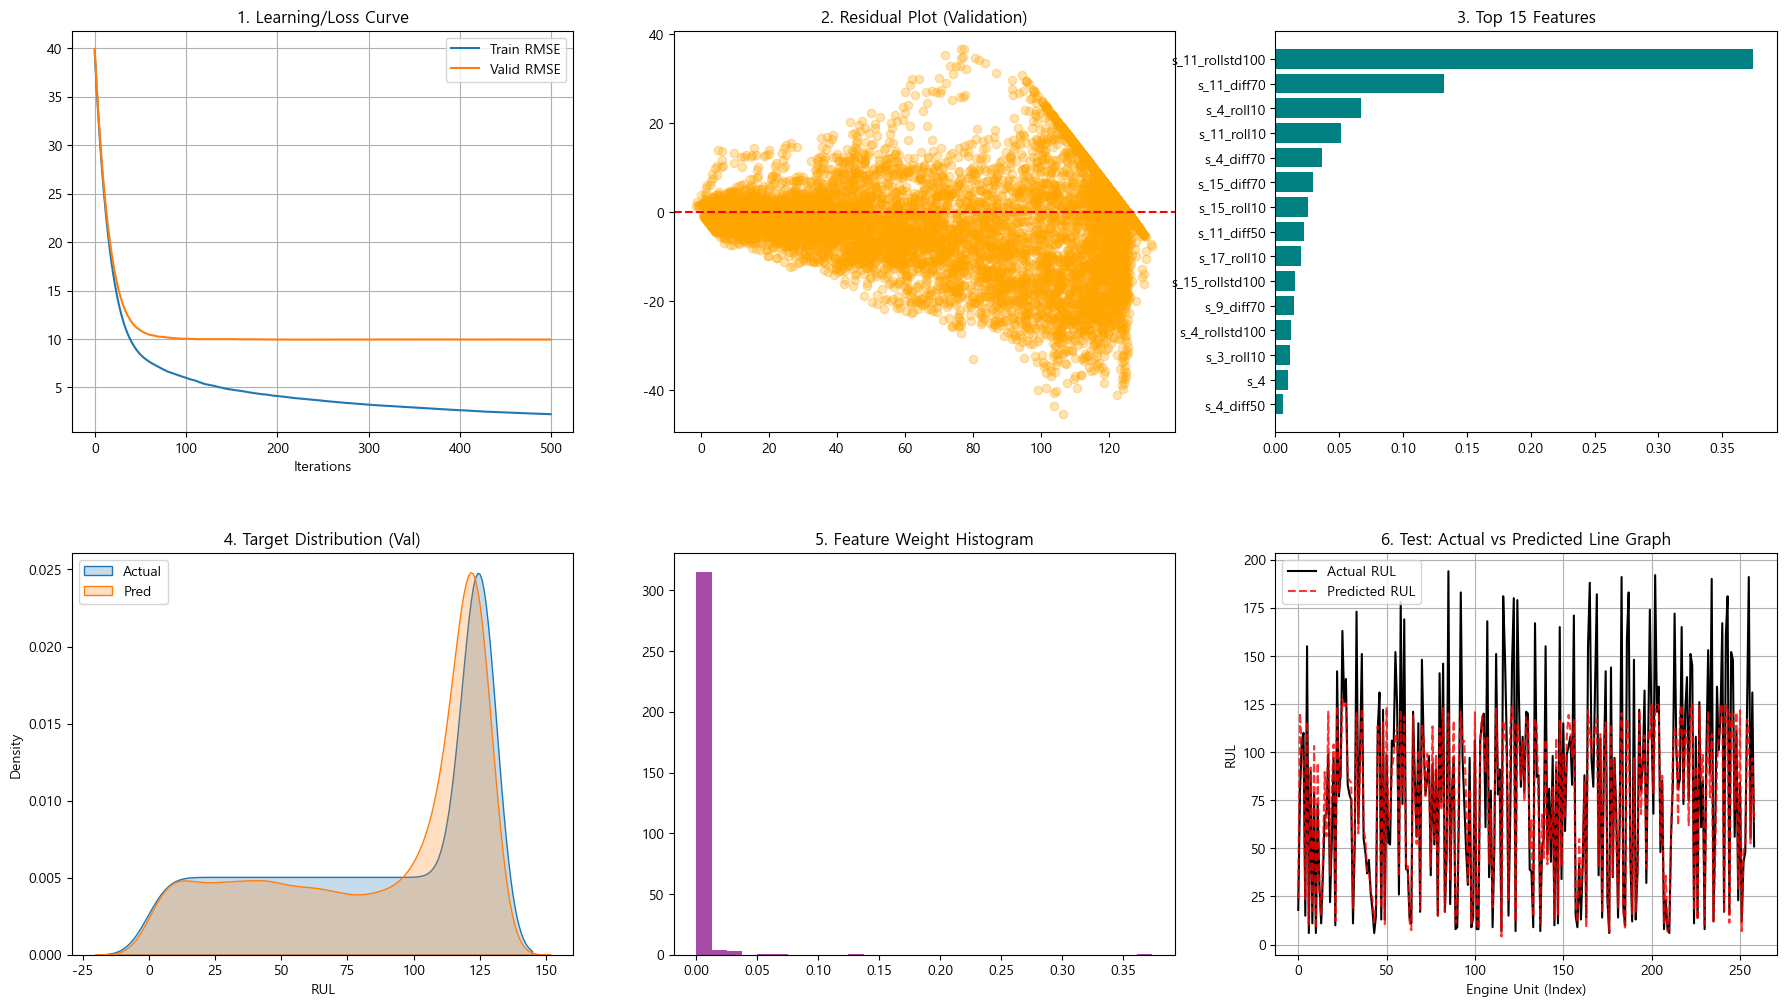

In [31]:
import xgboost as xgb

# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, f'XGBoost ({XGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_xgb)


 🏆 LightGBM (gpu) 최종 평가 결과 
 [Train] RMSE: 5.0502 | NASA Score: 20543.91
 [Valid] RMSE: 10.0391 | NASA Score: 18203.09
 [Test] RMSE: 24.6786 | NASA Score: 5010.39


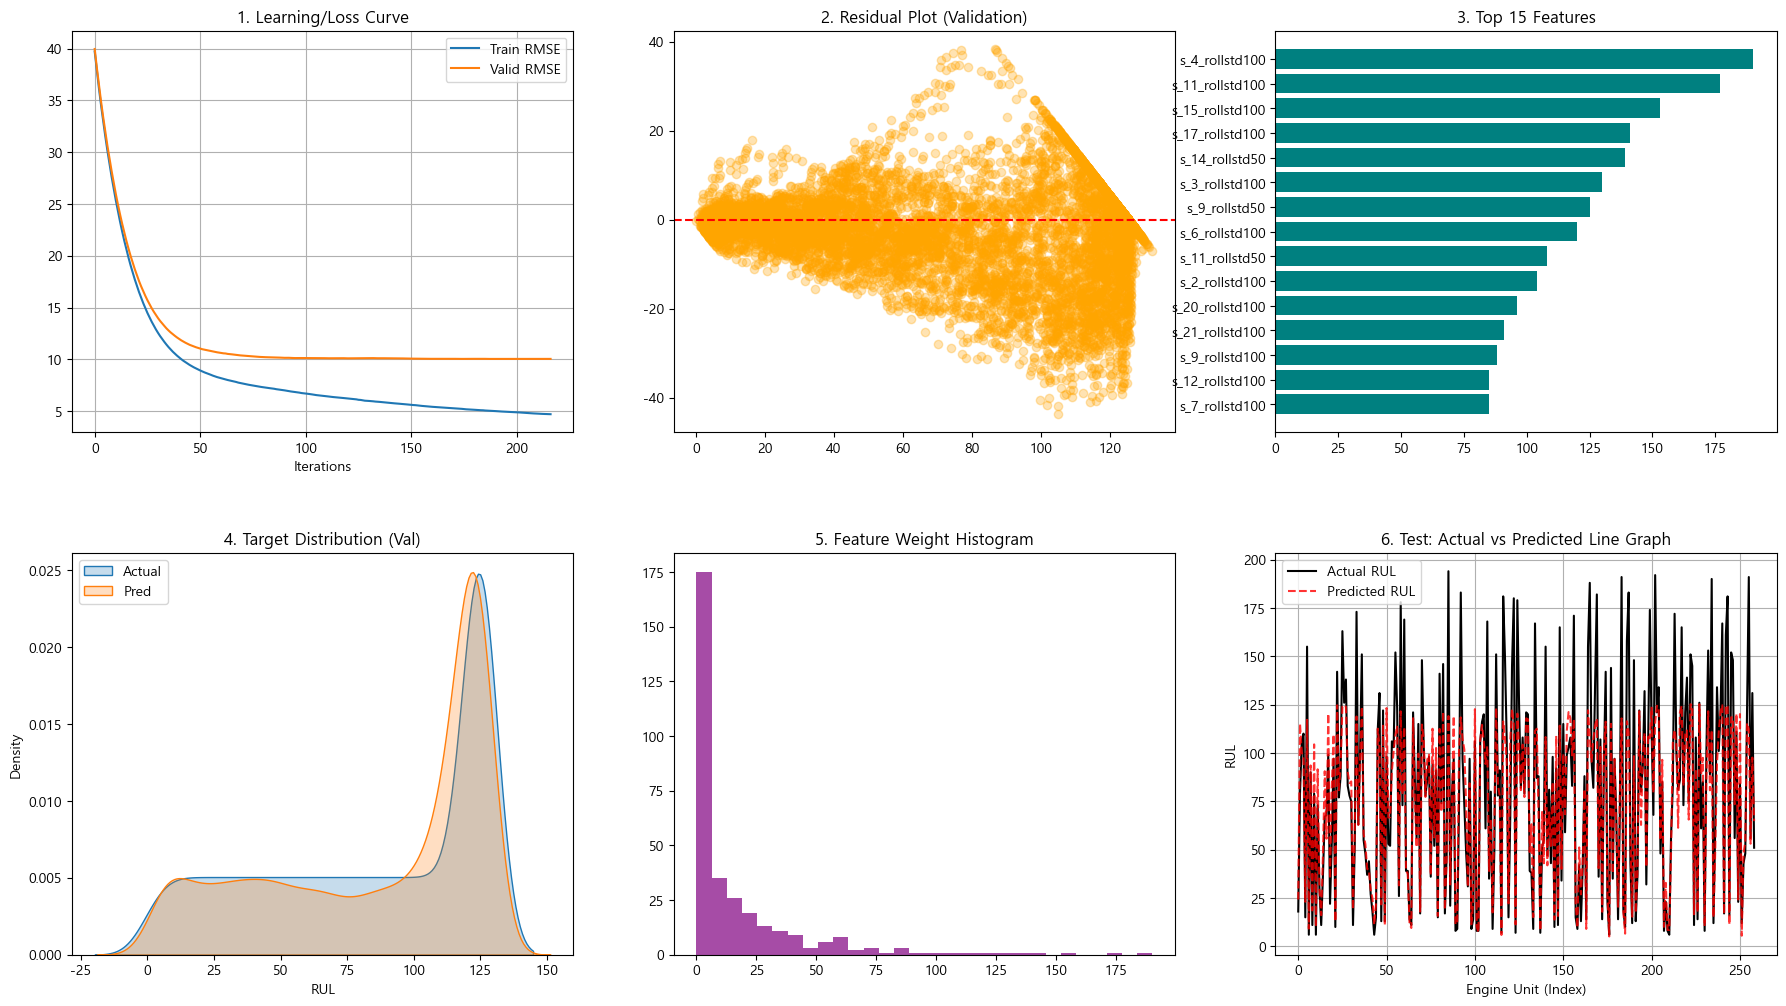

In [32]:
import lightgbm as lgb

# --- 하이퍼파라미터 설정 ---
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
res_lgb  = model_lgb.evals_result_
eval_dict_lgb = {'train': res_lgb['training']['rmse'],
                 'valid': res_lgb['valid_1']['rmse']}
evaluate_full_pipeline(model_lgb, f'LightGBM ({LGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_lgb)


Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 12.0665	training's l2: 145.6	valid_1's rmse: 14.0658	valid_1's l2: 197.846
[100]	training's rmse: 6.72599	training's l2: 45.239	valid_1's rmse: 10.4102	valid_1's l2: 108.373
[150]	training's rmse: 5.09126	training's l2: 25.9209	valid_1's rmse: 9.9942	valid_1's l2: 99.884
[200]	training's rmse: 4.19407	training's l2: 17.5902	valid_1's rmse: 9.97137	valid_1's l2: 99.4282
[250]	training's rmse: 3.67349	training's l2: 13.4945	valid_1's rmse: 9.96203	valid_1's l2: 99.242
[300]	training's rmse: 3.27922	training's l2: 10.7533	valid_1's rmse: 9.94708	valid_1's l2: 98.9445
[350]	training's rmse: 2.95623	training's l2: 8.73927	valid_1's rmse: 9.95487	valid_1's l2: 99.0995
Early stopping, best iteration is:
[301]	training's rmse: 3.27037	training's l2: 10.6953	valid_1's rmse: 9.94657	valid_1's l2: 98.9342

 🏆 LightGBM 최종 평가 결과 
 [Train] RMSE: 3.2704 | NASA Score: 11311.31
 [Valid] RMSE: 9.9466 | NASA Score: 17571.3

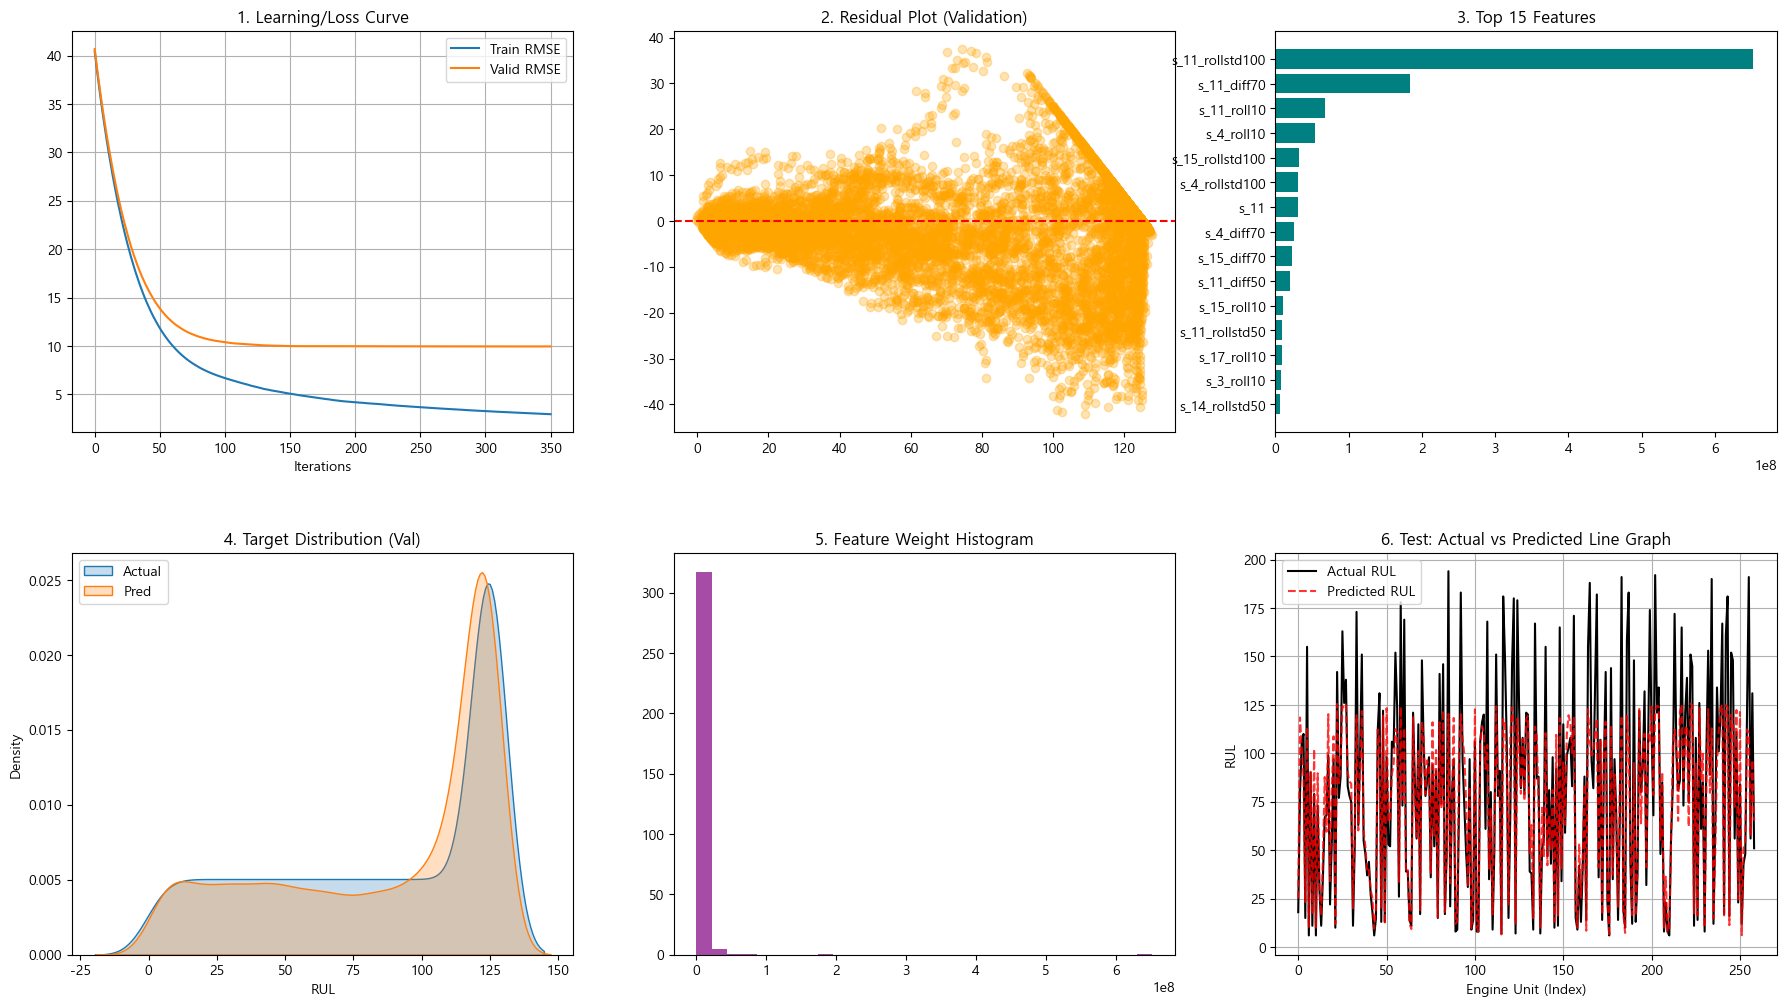

In [33]:
import lightgbm as lgb

# 1. 학습 데이터 준비
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val, y_val = valid_ml[ML_FEATURES], valid_ml['RUL']

# 2. 하이퍼파라미터 설정 (예측 지연 및 성능 최적화)
lgb_params = {
    'n_estimators': 1000,      # 충분한 학습을 위해 증가
    'learning_rate': 0.03,     # 세밀한 가중치 업데이트
    'max_depth': 8,            # FD002의 복잡한 패턴 학습을 위해 깊이 조정
    'num_leaves': 63,          # 리프 노드 수 확장
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'random_state': 42,
    'n_jobs': -1,
    'importance_type': 'gain',
    'verbosity': -1
}

# 3. 모델 초기화 및 학습
model_lgb = lgb.LGBMRegressor(**lgb_params)

# Early Stopping 적용 (검증 데이터 기준 50회 이상 개선 없을 시 중단)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)  # 50회마다 로그 출력
    ]
)

# 4. 학습 곡선 데이터 추출 (eval_dict 구성)
results = model_lgb.evals_result_
# LightGBM의 기본 eval_set 순서에 따라 training / valid_1로 매핑됩니다.
eval_dict = {
    'train': results['training']['rmse'], 
    'valid': results['valid_1']['rmse']
}

# 5. 최종 평가 및 시각화 실행
evaluate_full_pipeline(
    model_lgb, 
    "LightGBM", 
    is_tree=True, 
    is_boosting=True, 
    eval_results=eval_dict
)